# Heston PDE — Numerical Evaluation

**Course:** Partial Differential Equations with Applications in Physics and Industry  
**Authors:** Oliwier Arent, Filip Miśkiewicz, Natalia Przewdzięk

This notebook implements the computational pipeline for the project. Full mathematical derivations and extended interpretations are given in the accompanying LaTeX report (`main.tex` on Overleaf).

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Project root on the Python path (notebook may be run from any working directory).
ROOT = Path.cwd()
if not (ROOT / "utils").exists() and (ROOT.parent / "utils").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.black_scholes import (
    black_scholes_call,
    black_scholes_put,
    implied_volatility,
    put_call_parity_check,
)
from utils.heston_analytical import (
    black_scholes_limit_error,
    heston_call_price,
    heston_put_price,
)
from utils.grid_builder import (
    build_heston_grid,
    build_operators_with_boundary_conditions,
    mesh_spacing_stats,
)

FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

## 1. Black-Scholes baseline

We implement the analytical Black-Scholes pricer and implied-volatility inversion. This section establishes the reference model used throughout the project. The governing PDE is

$$
\frac{\partial V}{\partial t}
+ rS\frac{\partial V}{\partial S}
+ \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2}
- rV = 0.
$$

The full derivation and boundary conditions are given in Section 2 of the PDF report.

In [14]:
# Standard test parameters (same notation as in the report).
S0 = 100.0   # spot
K = 100.0    # strike (ATM)
T = 1.0      # maturity [years]
r = 0.05     # risk-free rate
sigma = 0.20 # constant volatility

call_price = black_scholes_call(S0, K, T, r, sigma)
put_price = black_scholes_put(S0, K, T, r, sigma)

print(f"ATM call price: {call_price:.4f}")
print(f"ATM put price:  {put_price:.4f}")
print(f"Put-call parity holds: {put_call_parity_check(call_price, put_price, S0, K, T, r)}")

ATM call price: 10.4506
ATM put price:  5.5735
Put-call parity holds: True


### Price curves vs. strike

Short sanity check: call (put) value decreases (increases) with strike at fixed maturity.

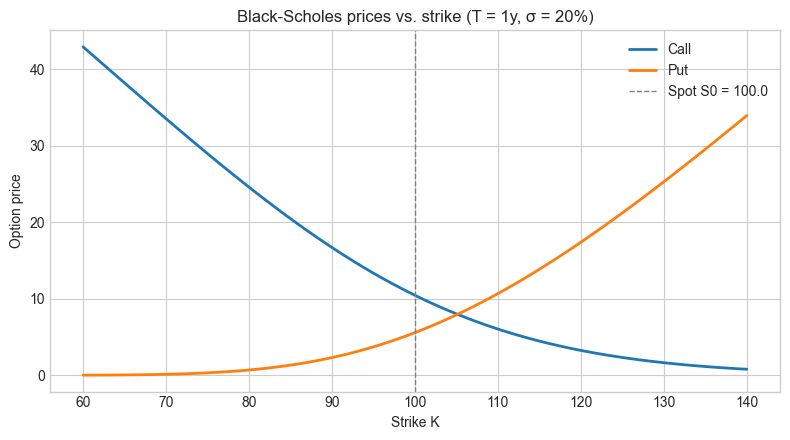

In [15]:
strikes = np.linspace(60, 140, 81)
call_curve = [black_scholes_call(S0, k, T, r, sigma) for k in strikes]
put_curve = [black_scholes_put(S0, k, T, r, sigma) for k in strikes]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, call_curve, label="Call", color="tab:blue", lw=2)
ax.plot(strikes, put_curve, label="Put", color="tab:orange", lw=2)
ax.axvline(S0, color="gray", ls="--", lw=1, label=f"Spot S0 = {S0}")
ax.set_xlabel("Strike K")
ax.set_ylabel("Option price")
ax.set_title("Black-Scholes prices vs. strike (T = 1y, σ = 20%)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "bs_price_curves.png", dpi=150)
plt.show()

### Implied volatility inversion

Given a market call price, Newton-Raphson on the Black-Scholes formula recovers the implied volatility $\sigma_{\mathrm{imp}}$ such that

$$
C_{\mathrm{BS}}(S, K, T, r, \sigma_{\mathrm{imp}}) = C_{\mathrm{market}}.
$$

This routine is reused later when comparing model-generated and market volatility smiles.

In [16]:
# Perturb the model price slightly to mimic a market quote.
market_call = call_price * 1.02
sigma_imp = implied_volatility(market_call, S0, K, T, r, option_type="call")

print(f"Model call (σ = {sigma:.0%}): {call_price:.4f}")
print(f"Perturbed market call:      {market_call:.4f}")
print(f"Recovered implied vol:      {sigma_imp:.4%}")
print(f"Round-trip price error:     {black_scholes_call(S0, K, T, r, sigma_imp) - market_call:.2e}")

Model call (σ = 20%): 10.4506
Perturbed market call:      10.6596
Recovered implied vol:      20.5566%
Round-trip price error:     6.86e-11


## 2. Heston model formulation

The Heston model extends Black-Scholes by replacing constant volatility with a stochastic variance process. Under the risk-neutral measure $\mathbb{Q}$,

$$
\mathrm{d}S_t = r S_t\,\mathrm{d}t + \sqrt{v_t}\,S_t\,\mathrm{d}W_t^{(1)},
$$

$$
\mathrm{d}v_t = \kappa(\theta - v_t)\,\mathrm{d}t + \xi\sqrt{v_t}\,\mathrm{d}W_t^{(2)},
\qquad
\mathrm{d}W_t^{(1)}\,\mathrm{d}W_t^{(2)} = \rho\,\mathrm{d}t.
$$

Applying Itô's lemma yields the two-dimensional pricing PDE (see Section 3 of the PDF report for the full derivation, boundary conditions, and the log-price transformation $x = \ln(S/K)$):

$$
\frac{\partial V}{\partial t}
+ rS\frac{\partial V}{\partial S}
+ \kappa(\theta - v)\frac{\partial V}{\partial v}
+ \frac{1}{2}vS^2\frac{\partial^2 V}{\partial S^2}
+ \rho\xi v S\frac{\partial^2 V}{\partial S\,\partial v}
+ \frac{1}{2}\xi^2 v\frac{\partial^2 V}{\partial v^2}
- rV = 0.
$$

No new code is required in this section; the numerical solver built on this formulation follows in later notebook sections.

## 3. Semi-analytical Heston benchmark

Unlike Black-Scholes, the Heston model has no elementary closed-form price. However, the affine structure yields a characteristic function $\varphi(u)$ of log-spot, and European calls can be recovered by Fourier inversion (Lewis, 2001):

$$
C = e^{-rT}\left(F - \frac{\sqrt{FK}}{2\pi}\int_0^\infty \mathrm{Re}\!\left[e^{-iu\ln(F/K)}\,\frac{\varphi(u-i/2)}{u^2 + 1/4}\right]\mathrm{d}u\right),
\qquad F = S_0 e^{rT}.
$$

We use the numerically stable characteristic-function formulation of Albrecher et al. (2007). This benchmark provides an exact reference for the ADI PDE solver convergence study. Details are in Section 4 of the PDF report.

In [17]:
# Reference Heston parameters (Feller condition satisfied: 2*kappa*theta > xi^2).
HESTON = dict(v0=0.04, kappa=2.0, theta=0.04, xi=0.3, rho=-0.7)
S0, r, T = 100.0, 0.05, 1.0
sigma_bs = HESTON["theta"] ** 0.5  # sqrt(theta) ~ 20% vol

atm_call = heston_call_price(S0, S0, T, r, **HESTON)
atm_bs = black_scholes_call(S0, S0, T, r, sigma_bs)

atm_put = heston_put_price(S0, S0, T, r, **HESTON)
parity_lhs = atm_call - atm_put
parity_rhs = S0 - S0 * np.exp(-r * T)

print(f"Heston ATM call:   {atm_call:.4f}")
print(f"Black-Scholes ATM: {atm_bs:.4f}")
print(f"Put-call parity residual: {abs(parity_lhs - parity_rhs):.2e}")

Heston ATM call:   10.3942
Black-Scholes ATM: 10.4506
Put-call parity residual: 5.33e-15


### Price skew: Heston vs. Black-Scholes

With $\rho < 0$, stochastic volatility generates a leverage effect: out-of-the-money puts become relatively more expensive than the constant-volatility benchmark.

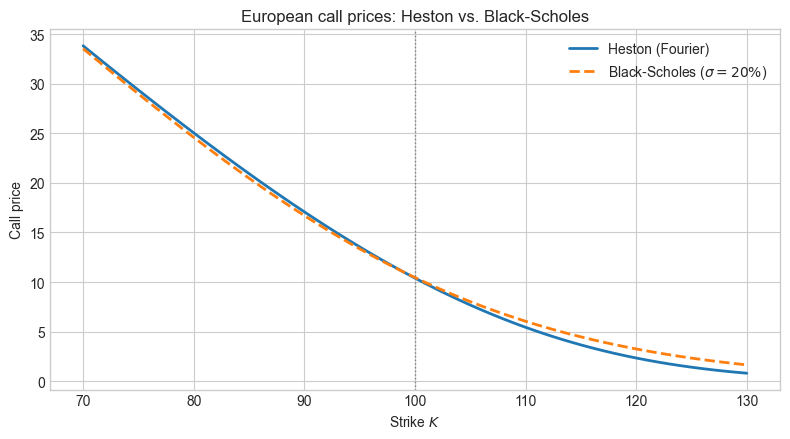

In [18]:
strikes = np.linspace(70, 130, 61)
heston_calls = [heston_call_price(S0, k, T, r, **HESTON) for k in strikes]
bs_calls = [black_scholes_call(S0, k, T, r, sigma_bs) for k in strikes]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(strikes, heston_calls, label="Heston (Fourier)", color="tab:blue", lw=2)
ax.plot(strikes, bs_calls, label=fr"Black-Scholes ($\sigma={sigma_bs * 100:.0f}\%$)", color="tab:orange", lw=2, ls="--")
ax.axvline(S0, color="gray", ls=":", lw=1)
ax.set_xlabel("Strike $K$")
ax.set_ylabel("Call price")
ax.set_title("European call prices: Heston vs. Black-Scholes")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "heston_vs_bs_strikes.png", dpi=150)
plt.show()

### Black-Scholes limiting case ($\xi \to 0$)

Setting $v_0 = \theta = \sigma^2$ and $\rho = 0$, the Heston price should converge to the Black-Scholes value as $\xi \to 0$.

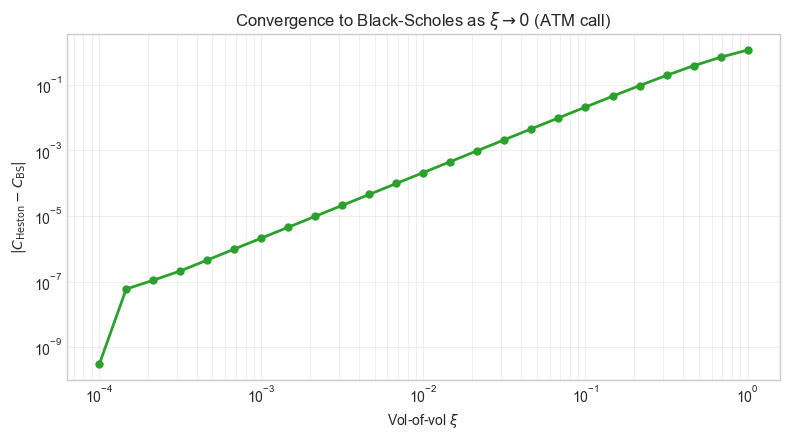

Smallest error: 2.98e-10 at xi = 1.0e-04


In [19]:
xi_grid, errors = black_scholes_limit_error(S0, S0, T, r, sigma_bs, kappa=HESTON["kappa"])

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(xi_grid, errors, "o-", color="tab:green", lw=2, ms=5)
ax.set_xlabel(r"Vol-of-vol $\xi$")
ax.set_ylabel(r"$|C_{\mathrm{Heston}} - C_{\mathrm{BS}}|$")
ax.set_title("Convergence to Black-Scholes as $\\xi \\to 0$ (ATM call)")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "heston_bs_limit.png", dpi=150)
plt.show()

print(f"Smallest error: {errors.min():.2e} at xi = {xi_grid[errors.argmin()]:.1e}")

## 4. Spatial grid and finite-difference operators

The Heston PDE is solved on a transformed domain in log-moneyness $x = \ln(S/K)$ and variance $v$. A uniform tensor-product grid would waste nodes away from the at-the-money strip and from the degenerate boundary $v=0$. We therefore use sinh stretching,

$$
x(\xi) = x_{\mathrm{mid}} + \frac{L}{2}\,\frac{\sinh(\mu_x \xi)}{\sinh(\mu_x)}, \qquad \xi \in [-1,1],
$$

$$
v(\eta) = v_{\max}\,\frac{\sinh(\mu_v \eta)}{\sinh(\mu_v)}, \qquad \eta \in [0,1].
$$

Non-uniform spacing enters one-dimensional finite-difference stencils for $\partial_x$, $\partial_{xx}$, $\partial_v$, and $\partial_{vv}$. Motivation, measured spacing statistics, and boundary design are in Section 5 of the PDF report.

In [ ]:
# Grid parameters for the ADI solver (refined in the convergence study).
GRID_NX = 81
GRID_NV = 41
X_MIN, X_MAX = -2.0, 2.0
V_MAX = 0.5
MU_X = 3.0
MU_V = 4.0

grid = build_heston_grid(
    nx=GRID_NX,
    nv=GRID_NV,
    x_min=X_MIN,
    x_max=X_MAX,
    v_max=V_MAX,
    concentration_x=MU_X,
    concentration_v=MU_V,
)

x_stats = mesh_spacing_stats(grid.dx_forward)
v_stats = mesh_spacing_stats(grid.dv_forward)

print(f"Grid size: {grid.nx} x {grid.nv} = {grid.nx * grid.nv:,} nodes")
print(f"x spacing: min={x_stats['min']:.4f}, max={x_stats['max']:.4f}, ratio={x_stats['ratio']:.2f}")
print(f"v spacing: min={v_stats['min']:.4f}, max={v_stats['max']:.4f}, ratio={v_stats['ratio']:.2f}")

### Grid spacing

Smaller $\Delta x$ and $\Delta v$ near $x=0$ and $v=0$ confirm the sinh clustering.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(grid.x[1:], grid.dx_forward, "o-", ms=3, lw=1.5)
axes[0].axvline(0.0, color="gray", ls=":", lw=1)
axes[0].set_xlabel(r"$x = \ln(S/K)$")
axes[0].set_ylabel(r"$\Delta x$")
axes[0].set_title("Log-moneyness spacing")

axes[1].plot(grid.v[1:], grid.dv_forward, "o-", ms=3, lw=1.5, color="tab:orange")
axes[1].set_xlabel(r"$v$")
axes[1].set_ylabel(r"$\Delta v$")
axes[1].set_title("Variance spacing")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "grid_spacing.png", dpi=150)
plt.show()

### Two-dimensional node layout

In [ ]:
X_mesh, V_mesh = np.meshgrid(grid.x, grid.v, indexing="ij")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(X_mesh.ravel(), V_mesh.ravel(), s=8, alpha=0.5, c="tab:blue")
ax.axvline(0.0, color="gray", ls="--", lw=1, label="ATM ($x=0$)")
ax.axhline(0.0, color="tomato", ls="--", lw=1, label=r"$v=0$ boundary")
ax.set_xlabel(r"$x = \ln(S/K)$")
ax.set_ylabel(r"$v$")
ax.set_title(f"Tensor-product grid ({grid.nx} x {grid.nv} nodes)")
ax.legend(loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "grid_nodes_2d.png", dpi=150)
plt.show()

### Finite-difference operators and boundary rows

European call: Dirichlet treatment in $x$ (values set by payoff/BC in the solver). Degenerate boundary $v=0$: Neumann $\partial u/\partial v = 0$.

In [ ]:
ops = build_operators_with_boundary_conditions(grid)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].spy(ops.D_xx, markersize=2)
axes[0].set_title(r"Sparsity of $D_{xx}$")
axes[1].spy(ops.D_vv, markersize=2)
axes[1].set_title(r"Sparsity of $D_{vv}$ (note $v=0$ row)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fd_operator_sparsity.png", dpi=150)
plt.show()

# Sanity check: row sums of interior second-derivative stencil should be ~0 (constant functions).
interior_rows = ops.D_xx.diagonal()[1:-1]
print(f"D_xx interior diagonal (sample): {interior_rows[grid.nx//2]:.4f}")
print(f"D_v row 0 (v=0 Neumann): {ops.D_v.getrow(0).toarray().flatten()[:4]}")
print(f"D_vv row 0 (v=0): {ops.D_vv.getrow(0).toarray().flatten()[:4]}")